### Visualizations

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

dfm4 = pd.read_csv('../data/dataMagic/cleanMagic.csv')
dfp2 = pd.read_csv('../data/dataPokemon/cleanPokemon.csv')
# dfm4 = pd.read_pickle("../data/dataMagic/cleanMagic.pkl")
# dfp2 = pd.read_pickle("../data/dataPokemon/cleanPokemon.pkl")

#### Line graph - release year value

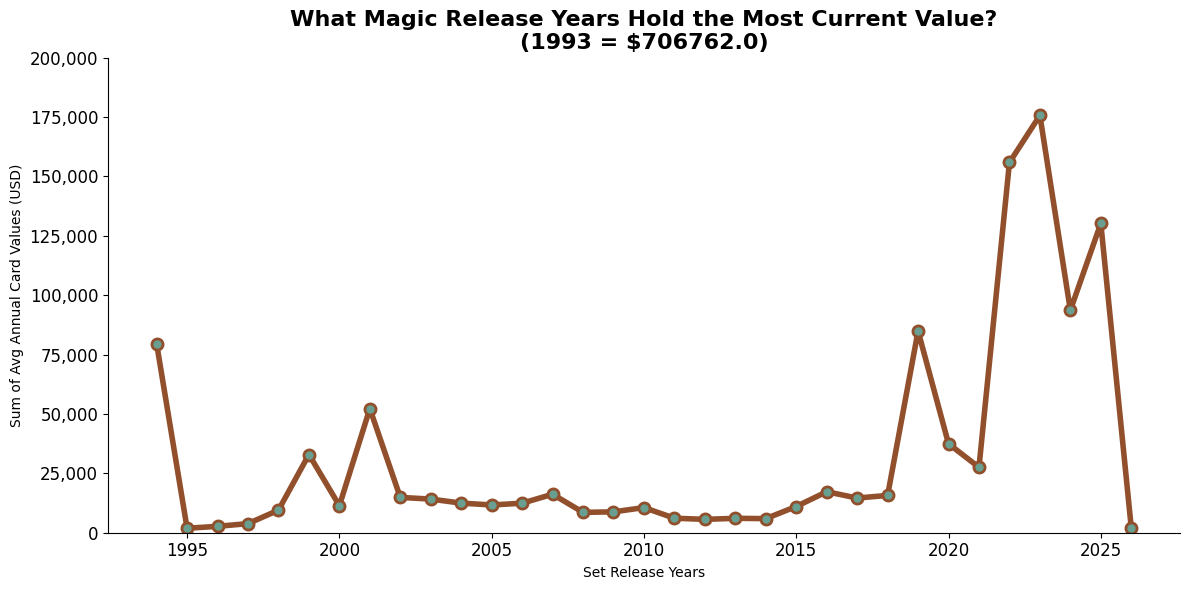

In [2]:
plt.figure(figsize=(12,6))

# 1993 Magic really skews the data, so it will be represented as a f-string in the title.
no1993 = dfm4[dfm4['releaseYear'] != 1993]
sumPerYearNo1993 = no1993.groupby("releaseYear")["avgMarketPrice"].sum().reset_index()

plt.plot(sumPerYearNo1993["releaseYear"], sumPerYearNo1993["avgMarketPrice"], color="#914F2C", linewidth=4, marker="o", markersize = 8, markerfacecolor = "#699F91", markeredgewidth = 2)
plt.ylim(0, 200000)
plt.xlabel("Set Release Years")
plt.ylabel("Sum of Avg Annual Card Values (USD)")

value1993 = dfm4.loc[dfm4["releaseYear"] == 1993, "avgMarketPrice"].sum().round()
plt.title(f"What Magic Release Years Hold the Most Current Value?\n(1993 = ${value1993})", fontsize=16, fontweight="bold", color="black")

ax = plt.gca()

# Show thousands comma for y-axis.
ax.yaxis.set_major_formatter(tkr.StrMethodFormatter('{x:,.0f}'))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

#### Line graph - release year value - Pokemon comparison

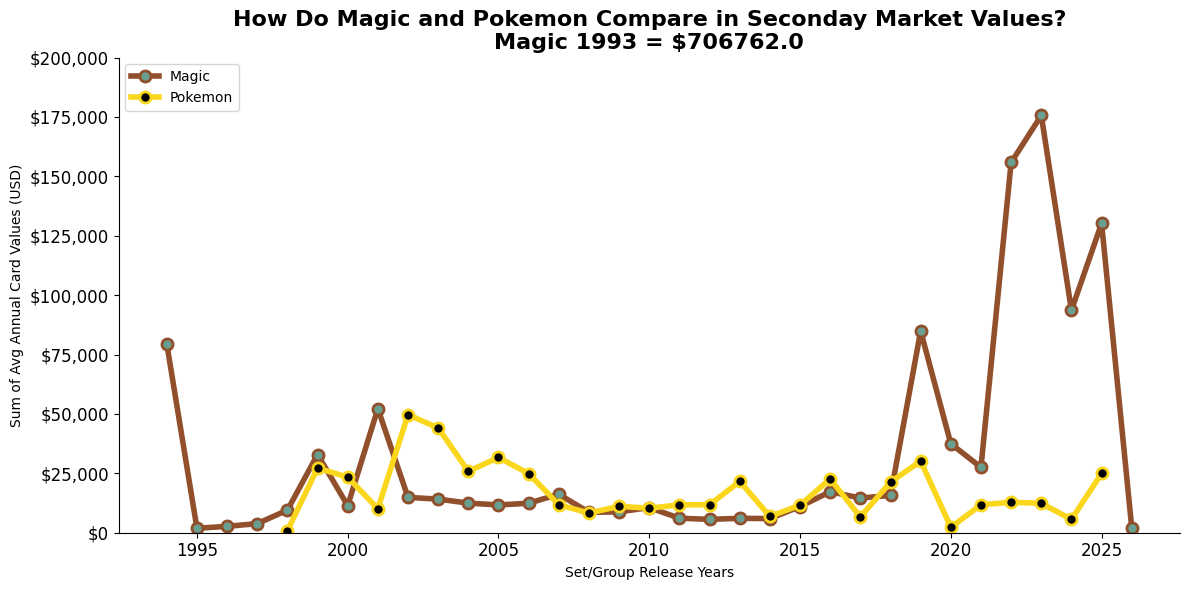

In [ ]:
plt.figure(figsize=(12,6))

# 1993 Magic really skews the data, so it will be represented as a f-string in the title.
dfm4No1993 = dfm4[dfm4['releaseYear'] != 1993]

# Set variables.
sumPerYearNo1993 = dfm4No1993.groupby("releaseYear")["avgMarketPrice"].sum().reset_index()
sumPerYearPokemon = dfp2.groupby("releaseYear")["marketPrice"].sum().reset_index()

# Plot Magic line.
plt.plot(sumPerYearNo1993["releaseYear"], sumPerYearNo1993["avgMarketPrice"], color="#914F2C", linewidth=4, marker="o", markersize = 8, markerfacecolor = "#699F91", 
         markeredgewidth = 2, label = 'Magic')

# Plot Pokemon line.
plt.plot(sumPerYearPokemon["releaseYear"], sumPerYearPokemon["marketPrice"], color="#FAD61D", linewidth=4, marker="o", markersize = 8, markerfacecolor = "#000000", 
         markeredgewidth = 2, label = "Pokemon")

plt.ylim(0, 200000)
plt.xlabel("Set/Group Release Years")
plt.ylabel("Sum of Avg Annual Card Values (USD)")

value_1993 = dfm4.loc[dfm4["releaseYear"] == 1993, "avgMarketPrice"].sum().round()
plt.title(f"How Do Magic and Pokemon Compare in Seconday Market Values?\nMagic 1993 = ${value_1993}", fontsize=16, fontweight="bold", color="black")

ax = plt.gca()

# Show $ and thousands comma for y-axis and rounds to nearest whole number.
ax.yaxis.set_major_formatter(tkr.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.despine()

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### Plotly line graph - release year value - Pokemon comparison

In [ ]:
# Group Magic without 1993.
dfm4No1993 = dfm4[dfm4['releaseYear'] != 1993]
sumPerYearNo1993 = dfm4No1993.groupby("releaseYear")["avgMarketPrice"].sum().reset_index()

# Group Pokemon data.
sumPerYearPokemon = dfp2.groupby("releaseYear")["marketPrice"].sum().reset_index()

# Create value for the title.
value_1993 = dfm4.loc[dfm4["releaseYear"] == 1993, "avgMarketPrice"].sum().round()

fig = go.Figure()

# Plot Magic line.
fig.add_trace(go.Scatter(
    x=sumPerYearNo1993["releaseYear"],
    y=sumPerYearNo1993["avgMarketPrice"],
    mode="lines+markers",
    name="Magic",
    line=dict(width=4, color="#914F2C"),
    marker=dict(size=10, color="#699F91", line=dict(width=2, color="#000000")),
    hovertemplate="<b>Magic</b><br>Year: %{x}<br>Value: $%{y:,.0f}<extra></extra>"
))

# Plot Pokemon line.
fig.add_trace(go.Scatter(
    x=sumPerYearPokemon["releaseYear"],
    y=sumPerYearPokemon["marketPrice"],
    mode="lines+markers",
    name="Pokemon",
    line=dict(width=4, color="#FAD61D"),
    marker=dict(size=10, color="#000000", line=dict(width=2, color="#000000")),
    hovertemplate="<b>Pokemon</b><br>Year: %{x}<br>Value: $%{y:,.0f}<extra></extra>"
))

# Determine layout.
fig.update_layout(
    title=dict(
        text=f"<b>How Do Magic and Pokemon Compare in Secondary Market Values?</b><br>"
             f"Magic 1993 = ${value_1993:,.0f}",
        x=0.5,
        font=dict(size=22)
    ),
    xaxis_title="Set/Group Release Years",
    yaxis_title="Sum of Avg Annual Card Values (USD)",
    yaxis=dict(range=[0, 200000], tickformat="$,.0f"),
    legend=dict(x=0.03, y=.95),
    width=1000,
    height=600
)

fig.show()

#### Bar graph - set value comparison

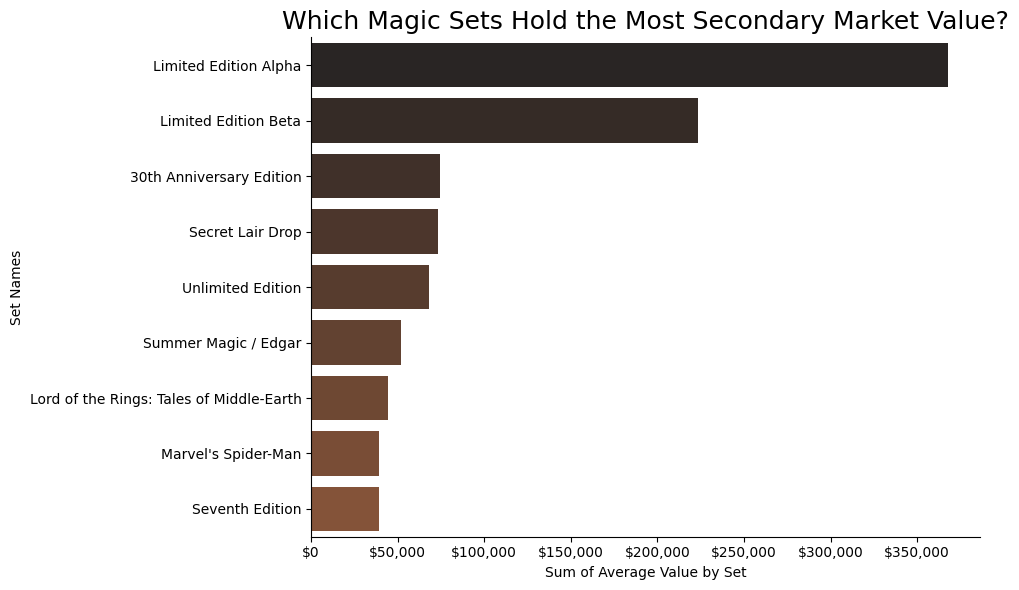

In [5]:
setAvg = (dfm4.groupby('setName')['avgMarketPrice'].sum().sort_values(ascending = False).reset_index())

plt.figure(figsize=(10,6))

sns.barplot(data = setAvg.head(9), x = 'avgMarketPrice', y='setName', palette = 'dark:#914F2C', hue = 'setName', width = 0.8, orient = 'h')
plt.title('Which Magic Sets Hold the Most Secondary Market Value?', fontsize=18)
plt.xlabel("Sum of Average Value by Set")
plt.ylabel("Set Names")

ax = plt.gca()
ax.set_ylim([8.5, -0.5])

# Show $ and thousands comma for x-axis and rounds to nearest whole number.
ax.xaxis.set_major_formatter(tkr.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.despine()
plt.tight_layout()
plt.show()

#### Treemap - highest valued card types and colors

In [ ]:
# Retrieve from queries.ipynb.
%store -r result4

fig = px.treemap(
    result4,
    # Hierarchy: type to color.
    path=['types', 'colors'],

    # Determines size of rectangles. 
    values='totalPrice',
    
    # Color by card color identity.
    color='colors',             
    
    # Color hex codes pulled from a Magic card back.
    color_discrete_map={
        'W': '#ECCC6C',  # white
        'U': '#35A9B9',  # blue
        'B': '#3D381F',  # black
        'R': '#E05519',  # red
        'G': '#7B9B03',  # green
        'C': "#914F2C",  # colorless
    },
    title="What top fifteen card types and colors hold the most value to consumers?"
)

fig.update_layout(
    width=900,
    height=600,
    title_font_size=22
)

fig.show()